# Halftone demo

As stated in the module, this code was mainly taken from [a stack overflow answer by fraxel](http://stackoverflow.com/a/10575940/250962) and forged into a [python module by philgyford](https://github.com/philgyford/python-halftone). Here we just optimised the interface for use in a notebook.

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from halftone import Halftone

In [6]:
import os

dir_path = '../img/photo'
file_list = sorted([os.path.join(dir_path,f) for f in os.listdir(dir_path) if f.endswith('.jpg')])
file_list

['../img/photo/00.jpg',
 '../img/photo/01.jpg',
 '../img/photo/02.jpg',
 '../img/photo/03.jpg',
 '../img/photo/04.jpg',
 '../img/photo/05.jpg',
 '../img/photo/06.jpg',
 '../img/photo/07.jpg']

In [7]:
from PIL import Image

imgs = dict()
for f in file_list:
    im = Image.open(f)
    im.thumbnail((800,800))
    im = Halftone(im).make()
    im.thumbnail((300,300))
    im = im.convert("RGB")
    imgs[os.path.basename(f)] = im

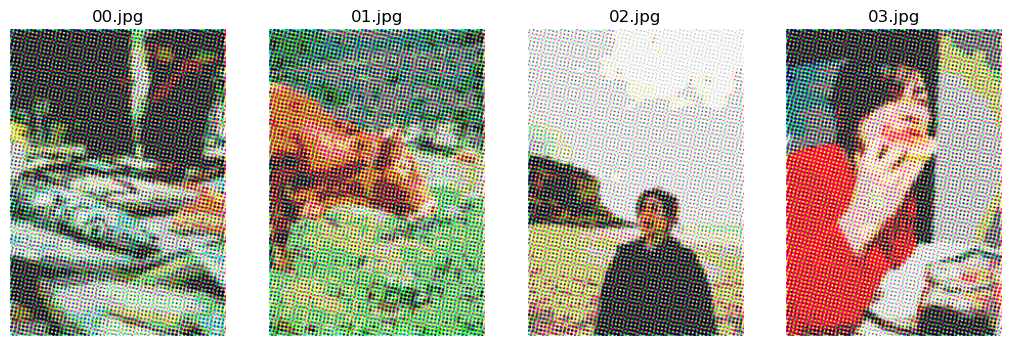

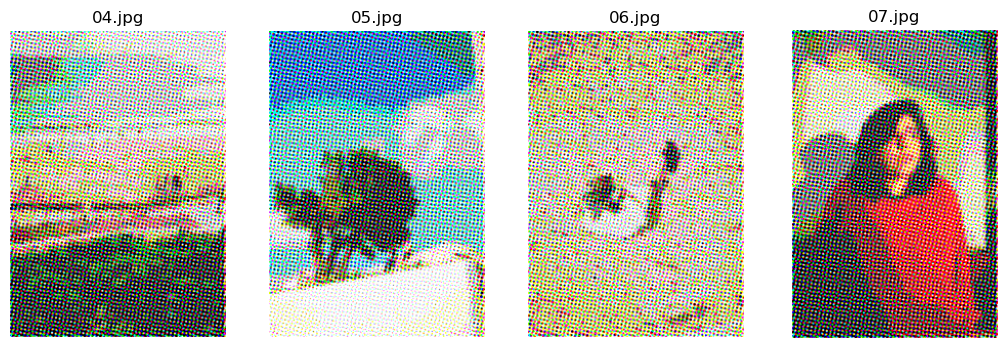

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def image_row(images, size=4):
    fig, axs = plt.subplots(1, len(images), figsize=(size*len(images)*0.8, size), squeeze=False)
    for ax, (key, img) in zip(axs[0], images.items()):
        ax.imshow(np.asarray(img))
        ax.set_title(str(key))
        ax.axis('off')
    return fig, axs

fig, axs = image_row({k: imgs[k] for k in ['00.jpg', '01.jpg', '02.jpg', '03.jpg']})
fig, axs = image_row({k: imgs[k] for k in ['04.jpg', '05.jpg', '06.jpg', '07.jpg']})